In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
quize1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz1/quiz1_marks.csv')
quize2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz2/quiz2_marks.csv')
quize3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz3/quiz3_marks.csv')


In [24]:

quize2

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00,Time taken (seconds),Quiz
0,5,Finished,14 March 2022 12:20 PM,17 March 2022 9:53 AM,2 days 21 hours,4.00,0.00,0.00,2.00,0.00,2.00,0.0,Quiz 2
1,1,Finished,14 March 2022 2:56 PM,14 March 2022 3:01 PM,4 mins 55 secs,6.00,0.00,2.00,2.00,2.00,0.00,295.0,Quiz 2
2,3,Finished,14 March 2022 6:48 PM,14 March 2022 7:13 PM,24 mins 55 secs,0.00,0.00,0.00,0.00,0.00,0.00,1495.0,Quiz 2
3,2,Finished,14 March 2022 7:22 PM,14 March 2022 7:57 PM,34 mins 51 secs,6.00,2.00,0.00,2.00,0.00,2.00,2091.0,Quiz 2
5,3,Finished,14 March 2022 8:08 PM,14 March 2022 8:08 PM,28 secs,10.00,2.00,2.00,2.00,2.00,2.00,28.0,Quiz 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10469,6652,Finished,20 March 2025 11:53 AM,20 March 2025 12:10 PM,16 mins 35 secs,8.00,2.00,2.00,2.00,0.00,2.00,995.0,Quiz 2
10470,6653,Finished,20 March 2025 1:19 PM,20 March 2025 1:21 PM,1 min 31 secs,6.00,2.00,0.00,2.00,0.00,2.00,91.0,Quiz 2
10471,6654,Finished,21 March 2025 4:13 PM,21 March 2025 4:17 PM,3 mins 5 secs,10.00,2.00,2.00,2.00,2.00,2.00,185.0,Quiz 2
10472,6655,Finished,21 March 2025 10:49 PM,21 March 2025 10:50 PM,1 min 2 secs,6.00,2.00,0.00,2.00,0.00,2.00,62.0,Quiz 2


In [5]:
import re
import numpy as np

def convert_time_to_seconds(time_str):
    if not isinstance(time_str, str) or time_str.strip() == '-' or time_str.strip() == '':
        return np.nan

    minutes = 0
    seconds = 0

    min_match = re.search(r'(\d+)\s*min(?:s)?', time_str)
    if min_match:
        minutes = int(min_match.group(1))

    sec_match = re.search(r'(\d+)\s*sec(?:s)?', time_str)
    if sec_match:
        seconds = int(sec_match.group(1))

    return minutes * 60 + seconds

quize1['Time taken (seconds)'] = quize1['Time taken'].apply(convert_time_to_seconds)
quize2['Time taken (seconds)'] = quize2['Time taken'].apply(convert_time_to_seconds)
quize3['Time taken (seconds)'] = quize3['Time taken'].apply(convert_time_to_seconds)

print("Updated quize1 dataframe head with new 'Time taken (seconds)' column:")
print(quize1[['Time taken', 'Time taken (seconds)']].head())

Updated quize1 dataframe head with new 'Time taken (seconds)' column:
        Time taken  Time taken (seconds)
0   7 mins 25 secs                 445.0
1     1 min 4 secs                  64.0
2                -                   NaN
3  17 mins 53 secs                1073.0
4          56 secs                  56.0


In [6]:
# Re-apply the conversion to get original NaNs in 'Time taken (seconds)'
# This is necessary as the previous 'fillna' operation would have modified the column.
quize1['Time taken (seconds)'] = quize1['Time taken'].apply(convert_time_to_seconds)
quize2['Time taken (seconds)'] = quize2['Time taken'].apply(convert_time_to_seconds)
quize3['Time taken (seconds)'] = quize3['Time taken'].apply(convert_time_to_seconds)

# Process quize1
initial_rows_quize1 = len(quize1)
quize1.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize1 = initial_rows_quize1 - len(quize1)
percentage_dropped_quize1 = (dropped_rows_quize1 / initial_rows_quize1) * 100 if initial_rows_quize1 > 0 else 0

# Process quize2
initial_rows_quize2 = len(quize2)
quize2.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize2 = initial_rows_quize2 - len(quize2)
percentage_dropped_quize2 = (dropped_rows_quize2 / initial_rows_quize2) * 100 if initial_rows_quize2 > 0 else 0

# Process quize3
initial_rows_quize3 = len(quize3)
quize3.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize3 = initial_rows_quize3 - len(quize3)
percentage_dropped_quize3 = (dropped_rows_quize3 / initial_rows_quize3) * 100 if initial_rows_quize3 > 0 else 0

print(f"Percentage of rows dropped in quize1: {percentage_dropped_quize1:.2f}%")
print(f"Percentage of rows dropped in quize2: {percentage_dropped_quize2:.2f}%")
print(f"Percentage of rows dropped in quize3: {percentage_dropped_quize3:.2f}%")

Percentage of rows dropped in quize1: 0.56%
Percentage of rows dropped in quize2: 0.42%
Percentage of rows dropped in quize3: 0.82%


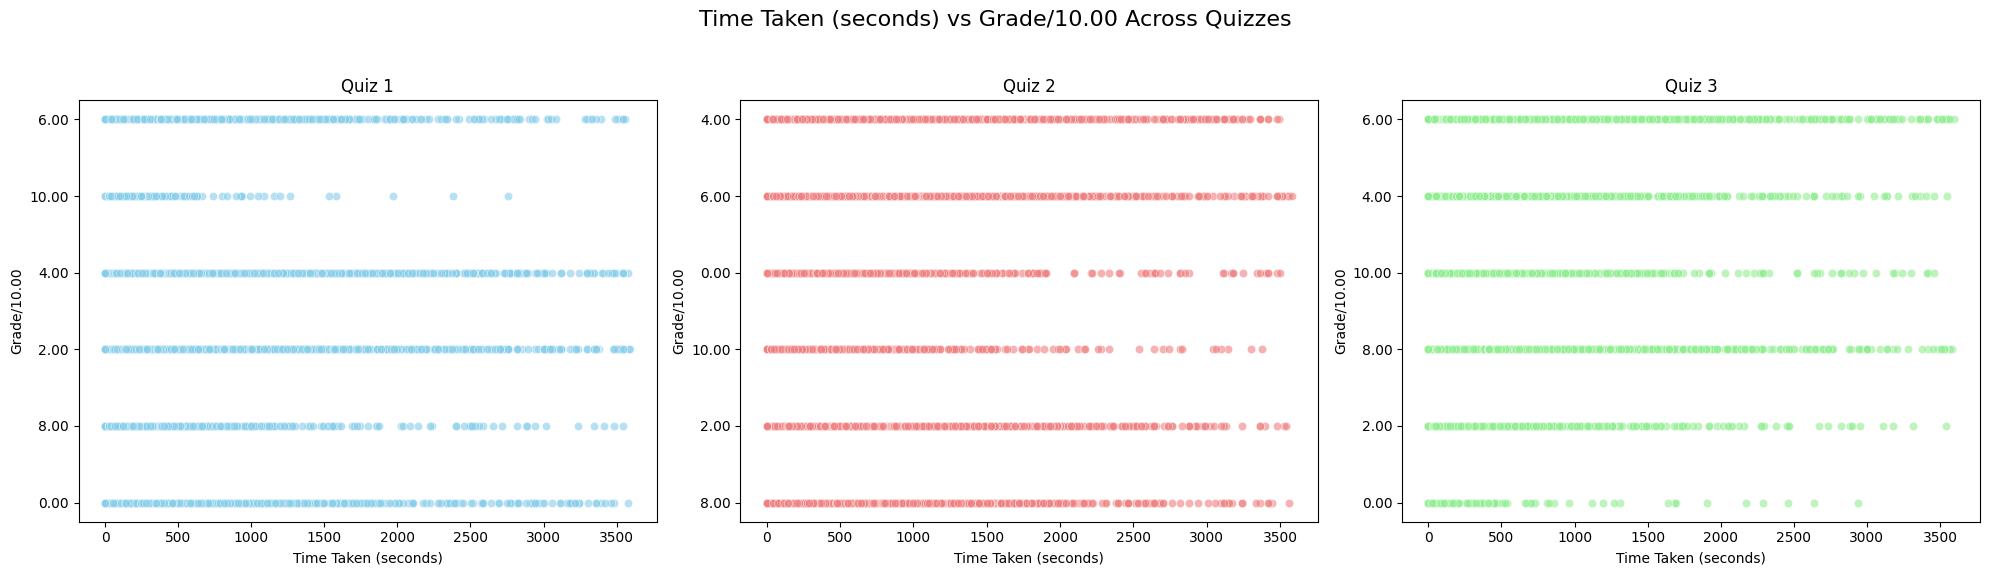

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Time Taken (seconds) vs Grade/10.00 Across Quizzes', fontsize=16)

# Scatter plot for Quiz 1
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize1, ax=axes[0], alpha=0.6, color='skyblue')
axes[0].set_title('Quiz 1')
axes[0].set_xlabel('Time Taken (seconds)')
axes[0].set_ylabel('Grade/10.00')

# Scatter plot for Quiz 2
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize2, ax=axes[1], alpha=0.6, color='lightcoral')
axes[1].set_title('Quiz 2')
axes[1].set_xlabel('Time Taken (seconds)')
axes[1].set_ylabel('Grade/10.00')

# Scatter plot for Quiz 3
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize3, ax=axes[2], alpha=0.6, color='lightgreen')
axes[2].set_title('Quiz 3')
axes[2].set_xlabel('Time Taken (seconds)')
axes[2].set_ylabel('Grade/10.00')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Bar plots for comparison between 3 quize grades


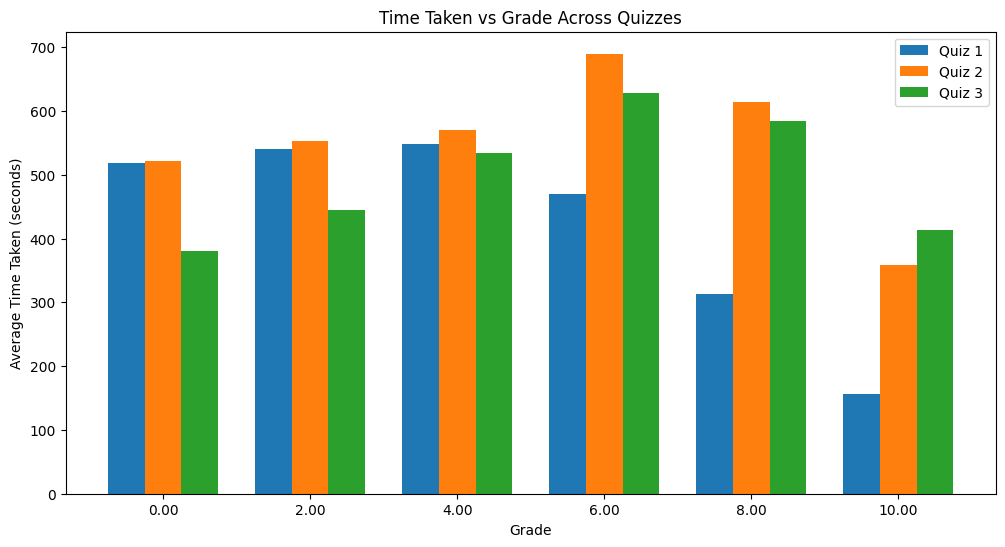

In [8]:
# Average time per grade
q1 = quize1.groupby('Grade/10.00')['Time taken (seconds)'].mean()
q2 = quize2.groupby('Grade/10.00')['Time taken (seconds)'].mean()
q3 = quize3.groupby('Grade/10.00')['Time taken (seconds)'].mean()

# grades = sorted(set(q1.index).union(q2.index).union(q3.index))
grades=['0.00','2.00','4.00','6.00','8.00','10.00']
q1 = q1.reindex(grades)
q2 = q2.reindex(grades)
q3 = q3.reindex(grades)

x = np.arange(len(grades))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, q1, width, label='Quiz 1')
plt.bar(x, q2, width, label='Quiz 2')
plt.bar(x + width, q3, width, label='Quiz 3')

plt.xlabel('Grade')
plt.ylabel('Average Time Taken (seconds)')
plt.title('Time Taken vs Grade Across Quizzes')

plt.xticks(x, grades)
plt.legend()

plt.show()

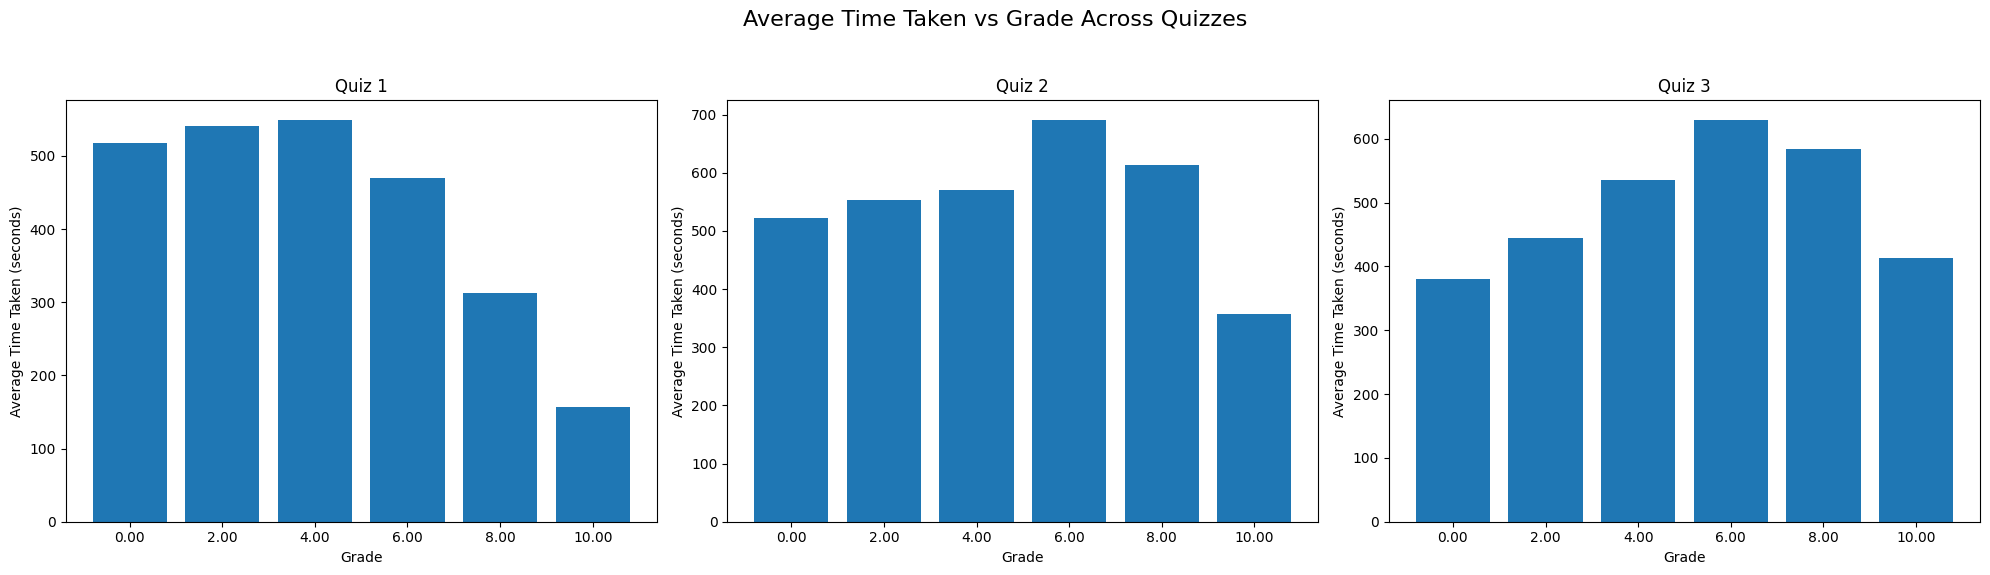

In [9]:
q1_avg = quize1.groupby('Grade/10.00')['Time taken (seconds)'].mean()
q2_avg = quize2.groupby('Grade/10.00')['Time taken (seconds)'].mean()
q3_avg = quize3.groupby('Grade/10.00')['Time taken (seconds)'].mean()


import matplotlib.pyplot as plt

grades = ['0.00','2.00','4.00','6.00','8.00','10.00']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Average Time Taken vs Grade Across Quizzes', fontsize=16)

quiz_data = [quize1, quize2, quize3]
titles = ['Quiz 1', 'Quiz 2', 'Quiz 3']

for i in range(3):
    avg = quiz_data[i].groupby('Grade/10.00')['Time taken (seconds)'].mean()

    # Reorder grades
    avg = avg.reindex(grades)

    axes[i].bar(grades, avg.values)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Grade')
    axes[i].set_ylabel('Average Time Taken (seconds)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Scatter plot

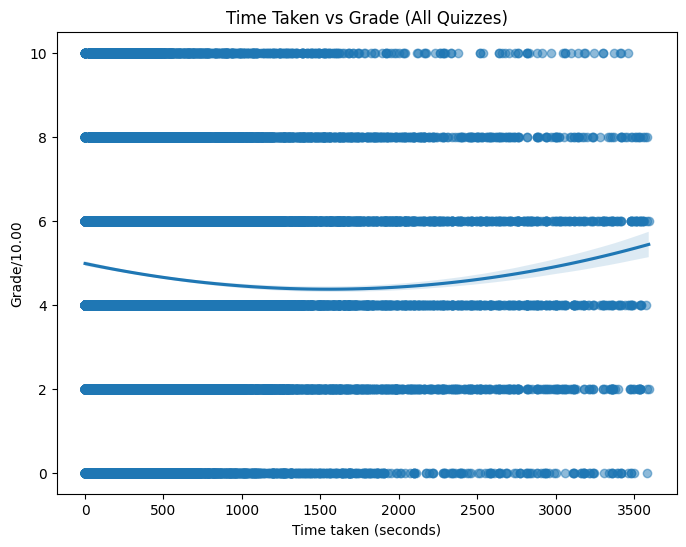

In [10]:
import pandas as pd

quize1['Quiz'] = 'Quiz 1'
quize2['Quiz'] = 'Quiz 2'
quize3['Quiz'] = 'Quiz 3'

df = pd.concat([quize1, quize2, quize3])
df['Grade/10.00'] = pd.to_numeric(df['Grade/10.00'], errors='coerce')
df['Time taken (seconds)'] = pd.to_numeric(df['Time taken (seconds)'], errors='coerce')
plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x='Time taken (seconds)',
    y='Grade/10.00',
    order=2,   # quadratic curve
    scatter_kws={'alpha':0.5}
)

plt.title('Time Taken vs Grade (All Quizzes)')
plt.show()

/tmp/ipykernel_19074/1142040326.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_grade = df.groupby('Time Bin')['Grade/10.00'].mean()


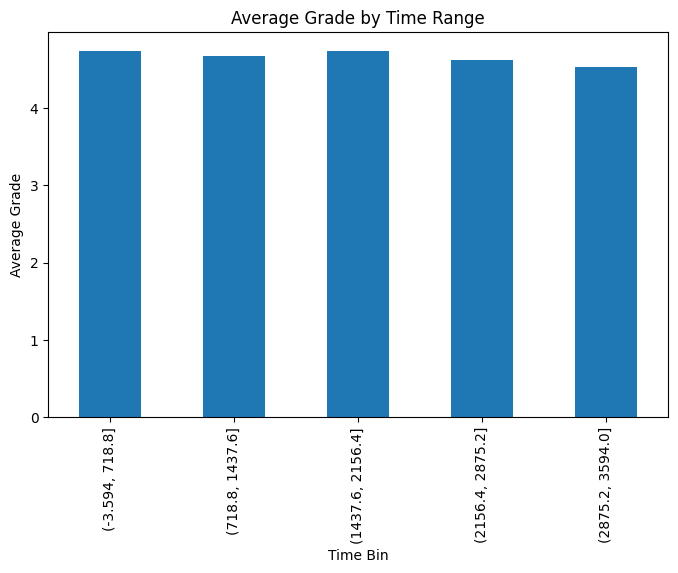

In [11]:
df['Time Bin'] = pd.cut(
    df['Time taken (seconds)'],
    bins=5
)

avg_grade = df.groupby('Time Bin')['Grade/10.00'].mean()

avg_grade.plot(kind='bar', figsize=(8,5))
plt.ylabel('Average Grade')
plt.title('Average Grade by Time Range')
plt.show()

In [12]:
import numpy as np

df['Time_sq'] = df['Time taken (seconds)'] ** 2

import statsmodels.formula.api as smf

model = smf.ols('Q("Grade/10.00") ~ Q("Time taken (seconds)") + Time_sq', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Q("Grade/10.00")   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     68.95
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.32e-30
Time:                        09:40:04   Log-Likelihood:                -79066.
No. Observations:               32407   AIC:                         1.581e+05
Df Residuals:                   32404   BIC:                         1.582e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

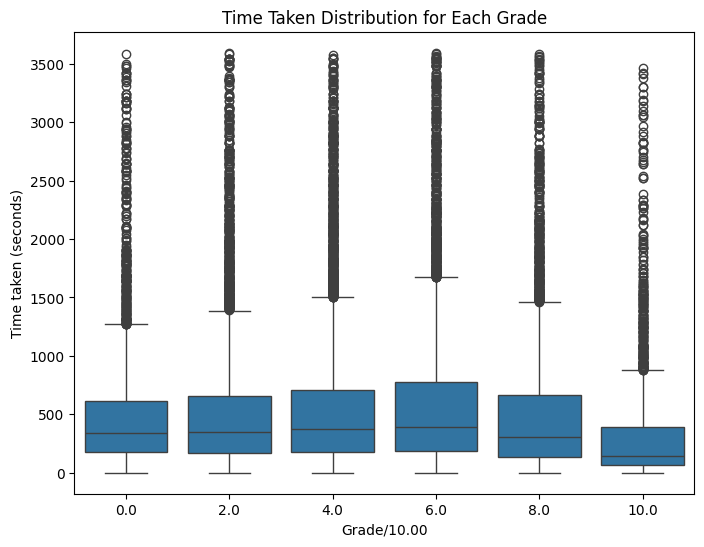

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='Grade/10.00',
    y='Time taken (seconds)'
)

plt.title('Time Taken Distribution for Each Grade')
plt.show()

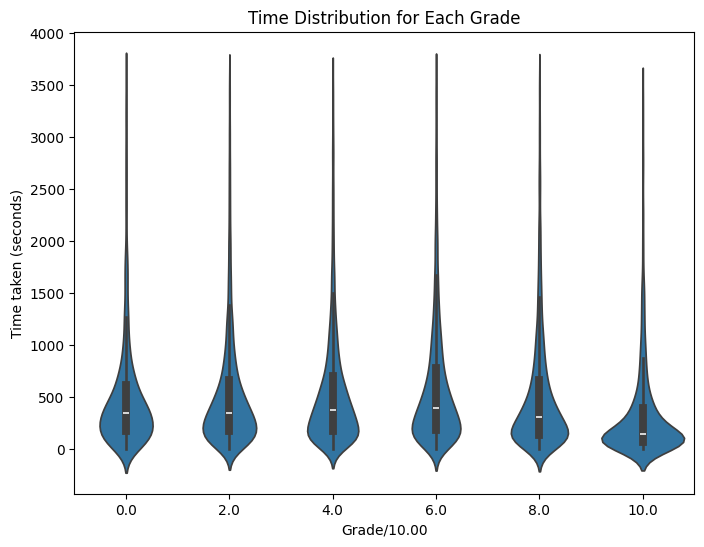

In [14]:
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df,
    x='Grade/10.00',
    y='Time taken (seconds)'
)

plt.title('Time Distribution for Each Grade')
plt.show()

Hour
0      807
1      430
2      276
3      142
4      150
5      253
6      508
7      916
8     1234
9     1767
10    2106
11    2305
12    2084
13    1969
14    2029
15    1838
16    1713
17    1608
18    1646
19    1882
20    1811
21    1858
22    1741
23    1334
Name: count, dtype: int64


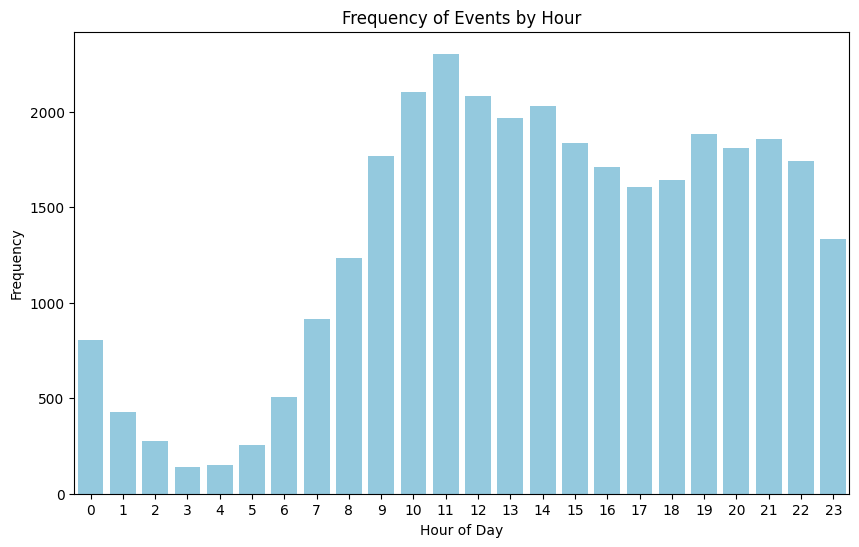

In [15]:
df['Started on'] = pd.to_datetime(df['Started on'], format="%d %B %Y %I:%M %p")
df['Hour'] = df['Started on'].dt.hour
hourly_counts = df['Hour'].value_counts().sort_index()
print(hourly_counts)

plt.figure(figsize=(10,6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.title('Frequency of Events by Hour')
plt.xticks(range(0,24))  # Show all hours
plt.show()

In [16]:


# Earliest and latest datetime
start_time = df['Started on'].min()
end_time = df['Started on'].max()

# Format to "14 March 2022 7:03 AM"
start_time_str = start_time.strftime("%d %B %Y %-I:%M %p")
end_time_str = end_time.strftime("%d %B %Y %-I:%M %p")

print(f"Starting time: {start_time_str}")
print(f"Ending time: {end_time_str}")

Starting time: 14 March 2022 6:55 AM
Ending time: 22 March 2025 4:57 PM


In [21]:
# Assuming quize1['Started on'] is already datetime
quize1['Year'] = quize1['Started on'].dt.year

yearly_counts = quize1['Year'].value_counts().sort_index()
print(yearly_counts)

Year
2022    4285
2023    5885
2024    3330
2025     411
Name: count, dtype: int64


In [22]:
quize_2022 = quize1[quize1['Started on'].dt.year == 2022]
start_time_2022 = quize_2022['Started on'].min()
end_time_2022 = quize_2022['Started on'].max()
# Format like "14 March 2022 6:55 AM"
start_time_str = start_time_2022.strftime("%d %B %Y %-I:%M %p")  # On Windows use %#I instead of %-I
end_time_str = end_time_2022.strftime("%d %B %Y %-I:%M %p")

print(f"Starting time in 2022: {start_time_str}")
print(f"Ending time in 2022: {end_time_str}")

Starting time in 2022: 14 March 2022 6:55 AM
Ending time in 2022: 31 December 2022 3:39 PM


   Student Code  quiz1  quiz2  quiz3
0             1    8.0    6.0    6.0
1             2    7.0    6.0    7.0
2             3    7.0    5.0    8.0
3             4    5.0    6.0    6.0
4             5    8.0    7.0    8.0
          quiz1     quiz2     quiz3
quiz1  1.000000  0.282371  0.304551
quiz2  0.282371  1.000000  0.207337
quiz3  0.304551  0.207337  1.000000


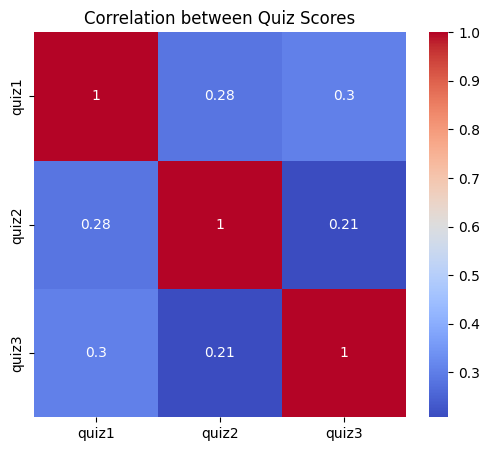

In [36]:
# Remove spaces, then convert to numeric
# quize1['Grade/10.00'] = pd.to_numeric(quize1['Grade/10.00'].str.strip(), errors='coerce')
# quize2['Grade/10.00'] = pd.to_numeric(quize2['Grade/10.00'].str.strip(), errors='coerce')
# quize3['Grade/10.00'] = pd.to_numeric(quize3['Grade/10.00'].str.strip(), errors='coerce')

quiz1_marks = quize1[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz1'})
quiz2_marks = quize2[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz2'})
quiz3_marks = quize3[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz3'})


# Merge quizzes
df_all = quiz1_marks.merge(quiz2_marks, on='Student Code', how='outer') \
                    .merge(quiz3_marks, on='Student Code', how='outer')

# Drop rows with any missing grades
df_all = df_all.dropna()

# Group by student and calculate mean per quiz
df_student = df_all.groupby('Student Code').mean().reset_index()

print(df_student.head())

# Correlation matrix
corr_matrix = df_student[['quiz1', 'quiz2', 'quiz3']].corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Quiz Scores')
plt.show()

In [35]:
df_all['Student Code']

,Student Code
0,1
1,1
2,2
3,2
4,2
...,...
33059,6654
33060,6654
33061,6655
33062,6655
